In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# Load dataset
df = pd.read_csv("Training Set_21.csv",index_col=0)
df

,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),...,diff_NPA(C28),SP_HOMO_L,SP_LUMO_L,SP_LU-HO_L,SP_μ_L,SP_η_L,Tolman_CA_int,B1_Sp2,B5_Sp2,L_Sp2
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,...,-0.065,-0.30016,0.05309,0.35325,-0.123535,0.176625,195.44,2.02,4.48,7.46
5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,...,-0.074,-0.29041,0.05333,0.34374,-0.118540,0.171870,195.44,2.05,4.47,7.46
5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,...,-0.055,-0.30363,0.05130,0.35493,-0.126165,0.177465,208.69,2.83,5.71,6.41
"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,...,-0.063,-0.30069,0.04423,0.34492,-0.128230,0.172460,246.68,4.00,8.05,7.46
5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,...,-0.052,-0.29232,0.03967,0.33199,-0.126325,0.165995,262.56,6.79,10.80,7.47
5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,...,-0.052,-0.29907,0.03739,0.33646,-0.130840,0.168230,262.78,5.32,8.18,7.46
5-IPent,4.00,1.00,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,166.60027,...,-0.044,-0.30297,0.04913,0.35210,-0.126920,0.176050,229.49,4.32,6.48,6.41
5-Np#,1.40,1.00,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,162.73663,...,-0.049,-0.28387,0.00880,0.29267,-0.137535,0.146335,261.73,4.92,10.24,10.22
5-IEt,1.00,1.33,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,174.90785,...,-0.063,-0.30067,0.04922,0.34989,-0.125725,0.174945,194.07,2.27,5.30,7.46


In [6]:
# Drop unwanted columns
df = df.drop(columns=["Exp_syn", "Exp_anti"])

In [7]:
df

,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),BA(N-C-N),%Vbur(3.5Å),...,diff_NPA(C28),SP_HOMO_L,SP_LUMO_L,SP_LU-HO_L,SP_μ_L,SP_η_L,Tolman_CA_int,B1_Sp2,B5_Sp2,L_Sp2
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,103.32507,37.6,...,-0.065,-0.30016,0.05309,0.35325,-0.123535,0.176625,195.44,2.02,4.48,7.46
5-IMes(Me),-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,103.18288,37.4,...,-0.074,-0.29041,0.05333,0.34374,-0.118540,0.171870,195.44,2.05,4.47,7.46
5-IPr,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,103.09034,45.5,...,-0.055,-0.30363,0.05130,0.35493,-0.126165,0.177465,208.69,2.83,5.71,6.41
"5-IPr*(Me, Ph)",0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,103.31600,49.4,...,-0.063,-0.30069,0.04423,0.34492,-0.128230,0.172460,246.68,4.00,8.05,7.46
5-IPr**,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,103.44216,54.2,...,-0.052,-0.29232,0.03967,0.33199,-0.126325,0.165995,262.56,6.79,10.80,7.47
5-IPr*,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,103.20629,54.2,...,-0.052,-0.29907,0.03739,0.33646,-0.130840,0.168230,262.78,5.32,8.18,7.46
5-IPent,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,166.60027,102.89045,51.1,...,-0.044,-0.30297,0.04913,0.35210,-0.126920,0.176050,229.49,4.32,6.48,6.41
5-Np#,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,162.73663,103.12006,49.6,...,-0.049,-0.28387,0.00880,0.29267,-0.137535,0.146335,261.73,4.92,10.24,10.22
5-IEt,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,174.90785,103.31904,42.8,...,-0.063,-0.30067,0.04922,0.34989,-0.125725,0.174945,194.07,2.27,5.30,7.46


In [8]:
print(df.columns)

Index(['ΔΔG_Exp', 'ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)', 'HOMO_L', 'LUMO_L',
       'LU-HO_L', 'μ_L', 'η_L', 'BA(N-C-N)_L', 'NPA(C28)_L', 'diff_NPA(C28)',
       'SP_HOMO_L', 'SP_LUMO_L', 'SP_LU-HO_L', 'SP_μ_L', 'SP_η_L',
       'Tolman_CA_int', 'B1_Sp2', 'B5_Sp2', 'L_Sp2'],
      dtype='str')


In [9]:
parm = ['ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)', 'HOMO_L', 'LUMO_L',
       'LU-HO_L', 'μ_L', 'η_L', 'BA(N-C-N)_L', 'NPA(C28)_L', 'diff_NPA(C28)',
       'SP_HOMO_L', 'SP_LUMO_L', 'SP_LU-HO_L', 'SP_μ_L', 'SP_η_L',
       'Tolman_CA_int', 'B1_Sp2', 'B5_Sp2', 'L_Sp2']
df_x = df[parm]
scaler = StandardScaler()
df[parm] = scaler.fit_transform(df_x)

In [10]:
df

,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),BA(N-C-N),%Vbur(3.5Å),...,diff_NPA(C28),SP_HOMO_L,SP_LUMO_L,SP_LU-HO_L,SP_μ_L,SP_η_L,Tolman_CA_int,B1_Sp2,B5_Sp2,L_Sp2
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,-0.484674,0.751057,0.751097,-0.829836,0.751098,-0.764500,0.325657,1.233000,-0.505051,-1.155344,...,-0.704978,-0.915897,0.667581,1.046088,-0.099146,1.046088,-1.058203,-0.761005,-0.818756,0.072542
5-IMes(Me),-0.411002,0.676138,0.676154,-0.696140,0.676157,-0.638478,-0.240488,1.215258,-0.530906,-1.186370,...,-1.425199,-0.008553,0.686867,0.497944,0.546212,0.497944,-1.058203,-0.739631,-0.823292,0.072542
5-IPr,0.411002,0.526365,0.526324,-0.397885,0.526326,-0.225883,0.414258,0.057494,-0.547733,0.070178,...,0.095267,-1.238819,0.523732,1.142921,-0.438945,1.142921,-0.572031,-0.183890,-0.260749,-1.121150
"5-IPr*(Me, Ph)",0.969348,-0.279410,-0.279401,0.245149,-0.279402,0.208291,-1.383290,-0.968035,-0.506700,0.675182,...,-0.544929,-0.965220,-0.044429,0.565957,-0.705744,0.565957,0.821905,0.649722,0.800825,0.072542
5-IPr**,1.268993,-2.208720,-2.209028,2.949785,-2.209024,-0.133956,0.204018,-0.606839,-0.483759,1.419803,...,0.335341,-0.186299,-0.410881,-0.179311,-0.459617,-0.179311,1.404577,2.637564,2.048401,0.083910
5-IPr*,1.308833,-1.010271,-1.010184,0.740418,-1.010187,-0.123598,0.204018,-1.078242,-0.526649,1.419803,...,0.335341,-0.814461,-0.594107,0.078334,-1.042959,0.078334,1.412649,1.590206,0.859801,0.072542
5-IPent,0.969348,0.226758,0.226614,0.164768,0.226617,0.047741,-0.437212,-0.800311,-0.584081,0.938902,...,0.975537,-1.177399,0.349346,0.979803,-0.536491,0.979803,0.191166,0.877718,0.088573,-1.121150
5-Np#,0.235274,-2.183742,-2.183603,1.736543,-2.183609,-0.786943,-0.213457,-1.711392,-0.542329,0.706208,...,0.575415,0.600066,-2.891663,-2.445665,-1.907958,-2.445665,1.374123,1.305211,1.794349,3.210247
5-IEt,-0.199408,0.601258,0.601243,-0.539202,0.601246,-0.365716,-0.308065,1.158692,-0.506147,-0.348672,...,-0.544929,-0.963358,0.356579,0.852422,-0.382096,0.852422,-1.108471,-0.582883,-0.446751,0.072542


In [11]:
# Define target column
target_column = "ΔΔG_Exp"

In [12]:
# Separate features (X) and target (y)
X = df.drop(columns=[target_column])  # Features
y = df[target_column]  # Target variable

In [13]:
X_train = X
y_train = y

In [14]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# Get feature importances
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

In [16]:
# Rank features by importance
ranked_features = feature_importance.sort_values(ascending=False)

In [17]:
# Display results
print(ranked_features)

B5_Sp2               0.140609
%Vbur(3.0Å)          0.078081
E_C12(LP)-Pd(LP*)    0.077648
E_Pd(LP)             0.068342
ΔH(RwB97XD)_int      0.059190
                       ...   
LU-HO_L              0.000739
NPA (C28)            0.000647
L_Sp2                0.000636
BA(N-C-N)_L          0.000367
LUMO_L               0.000347
Length: 61, dtype: float64


In [18]:
# Define a threshold (e.g., remove features with importance < 0.033)
threshold = 0.033
filtered_features = ranked_features[ranked_features > threshold]

B5_Sp2               0.140609
%Vbur(3.0Å)          0.078081
E_C12(LP)-Pd(LP*)    0.077648
E_Pd(LP)             0.068342
ΔH(RwB97XD)_int      0.059190
B1_Sp2               0.055177
%Vbur(3.5Å)          0.043847
E_dz2_Pd             0.036972
Occ.(dxy)_Pd         0.034517
SP_MC(C12)           0.033678
diff_NPA(C28)        0.033153
dtype: float64


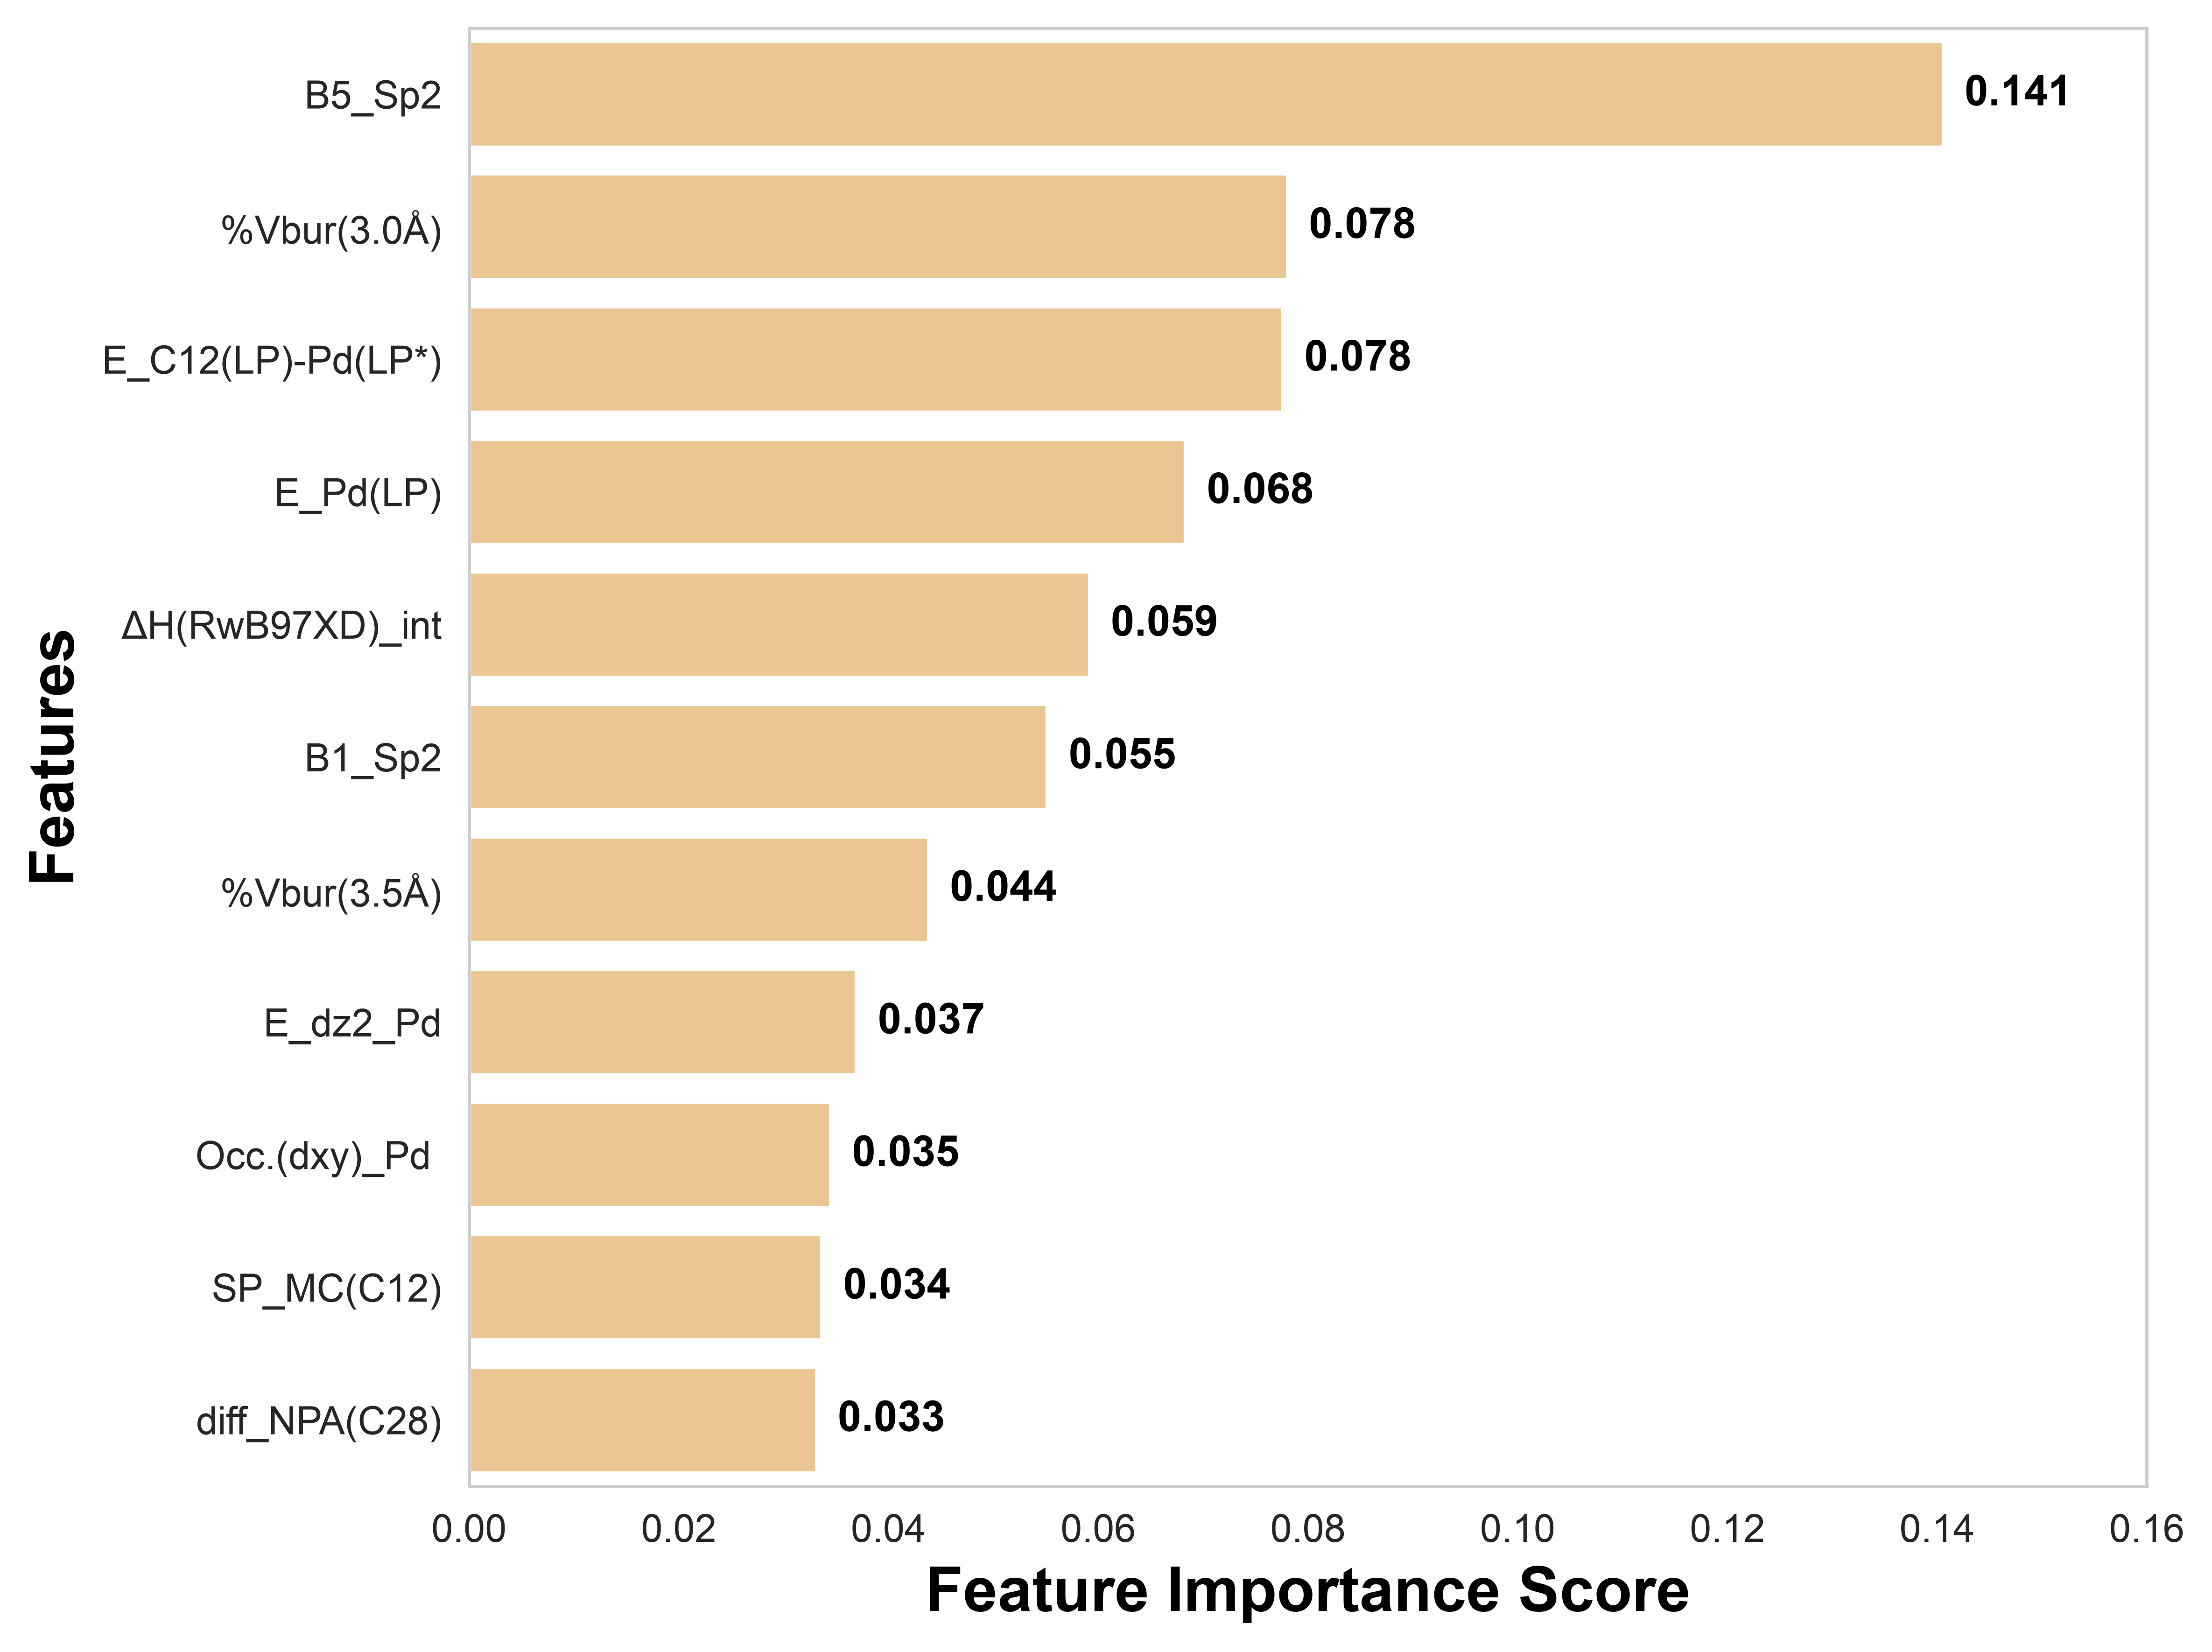

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if filtered_features has data
print(filtered_features)

# Set plot style
sns.set_style("whitegrid")

# Create figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

# Light ornage color
bar_color = "#FBC883"

# Plot the bar chart
sns.barplot(
    x=filtered_features.values,
    y=filtered_features.index,
    ax=ax,
    color=bar_color
)

# Remove gridlines
ax.grid(False)

# Add values on bars
for i, value in enumerate(filtered_features.values):
    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Customize labels
ax.set_xlabel(
    "Feature Importance Score",
    fontsize=16,
    fontweight="bold",
    color="black"
)

ax.set_ylabel(
    "Features",
    fontsize=16,
    fontweight="bold",
    color="black"
)

# Extend x-axis
ax.set_xlim(0, 0.16)

# Improve layout
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save high-resolution PNG
plt.savefig(
    "Figure 4A.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

# Show plot
plt.show()

In [20]:
top_n = 6  # Adjust the number of features as needed
important_features = filtered_features.index[:top_n]

In [21]:
# Extract relevant data from your dataset
df_selected = df[important_features]

In [22]:
corr_matrix = df_selected.corr()

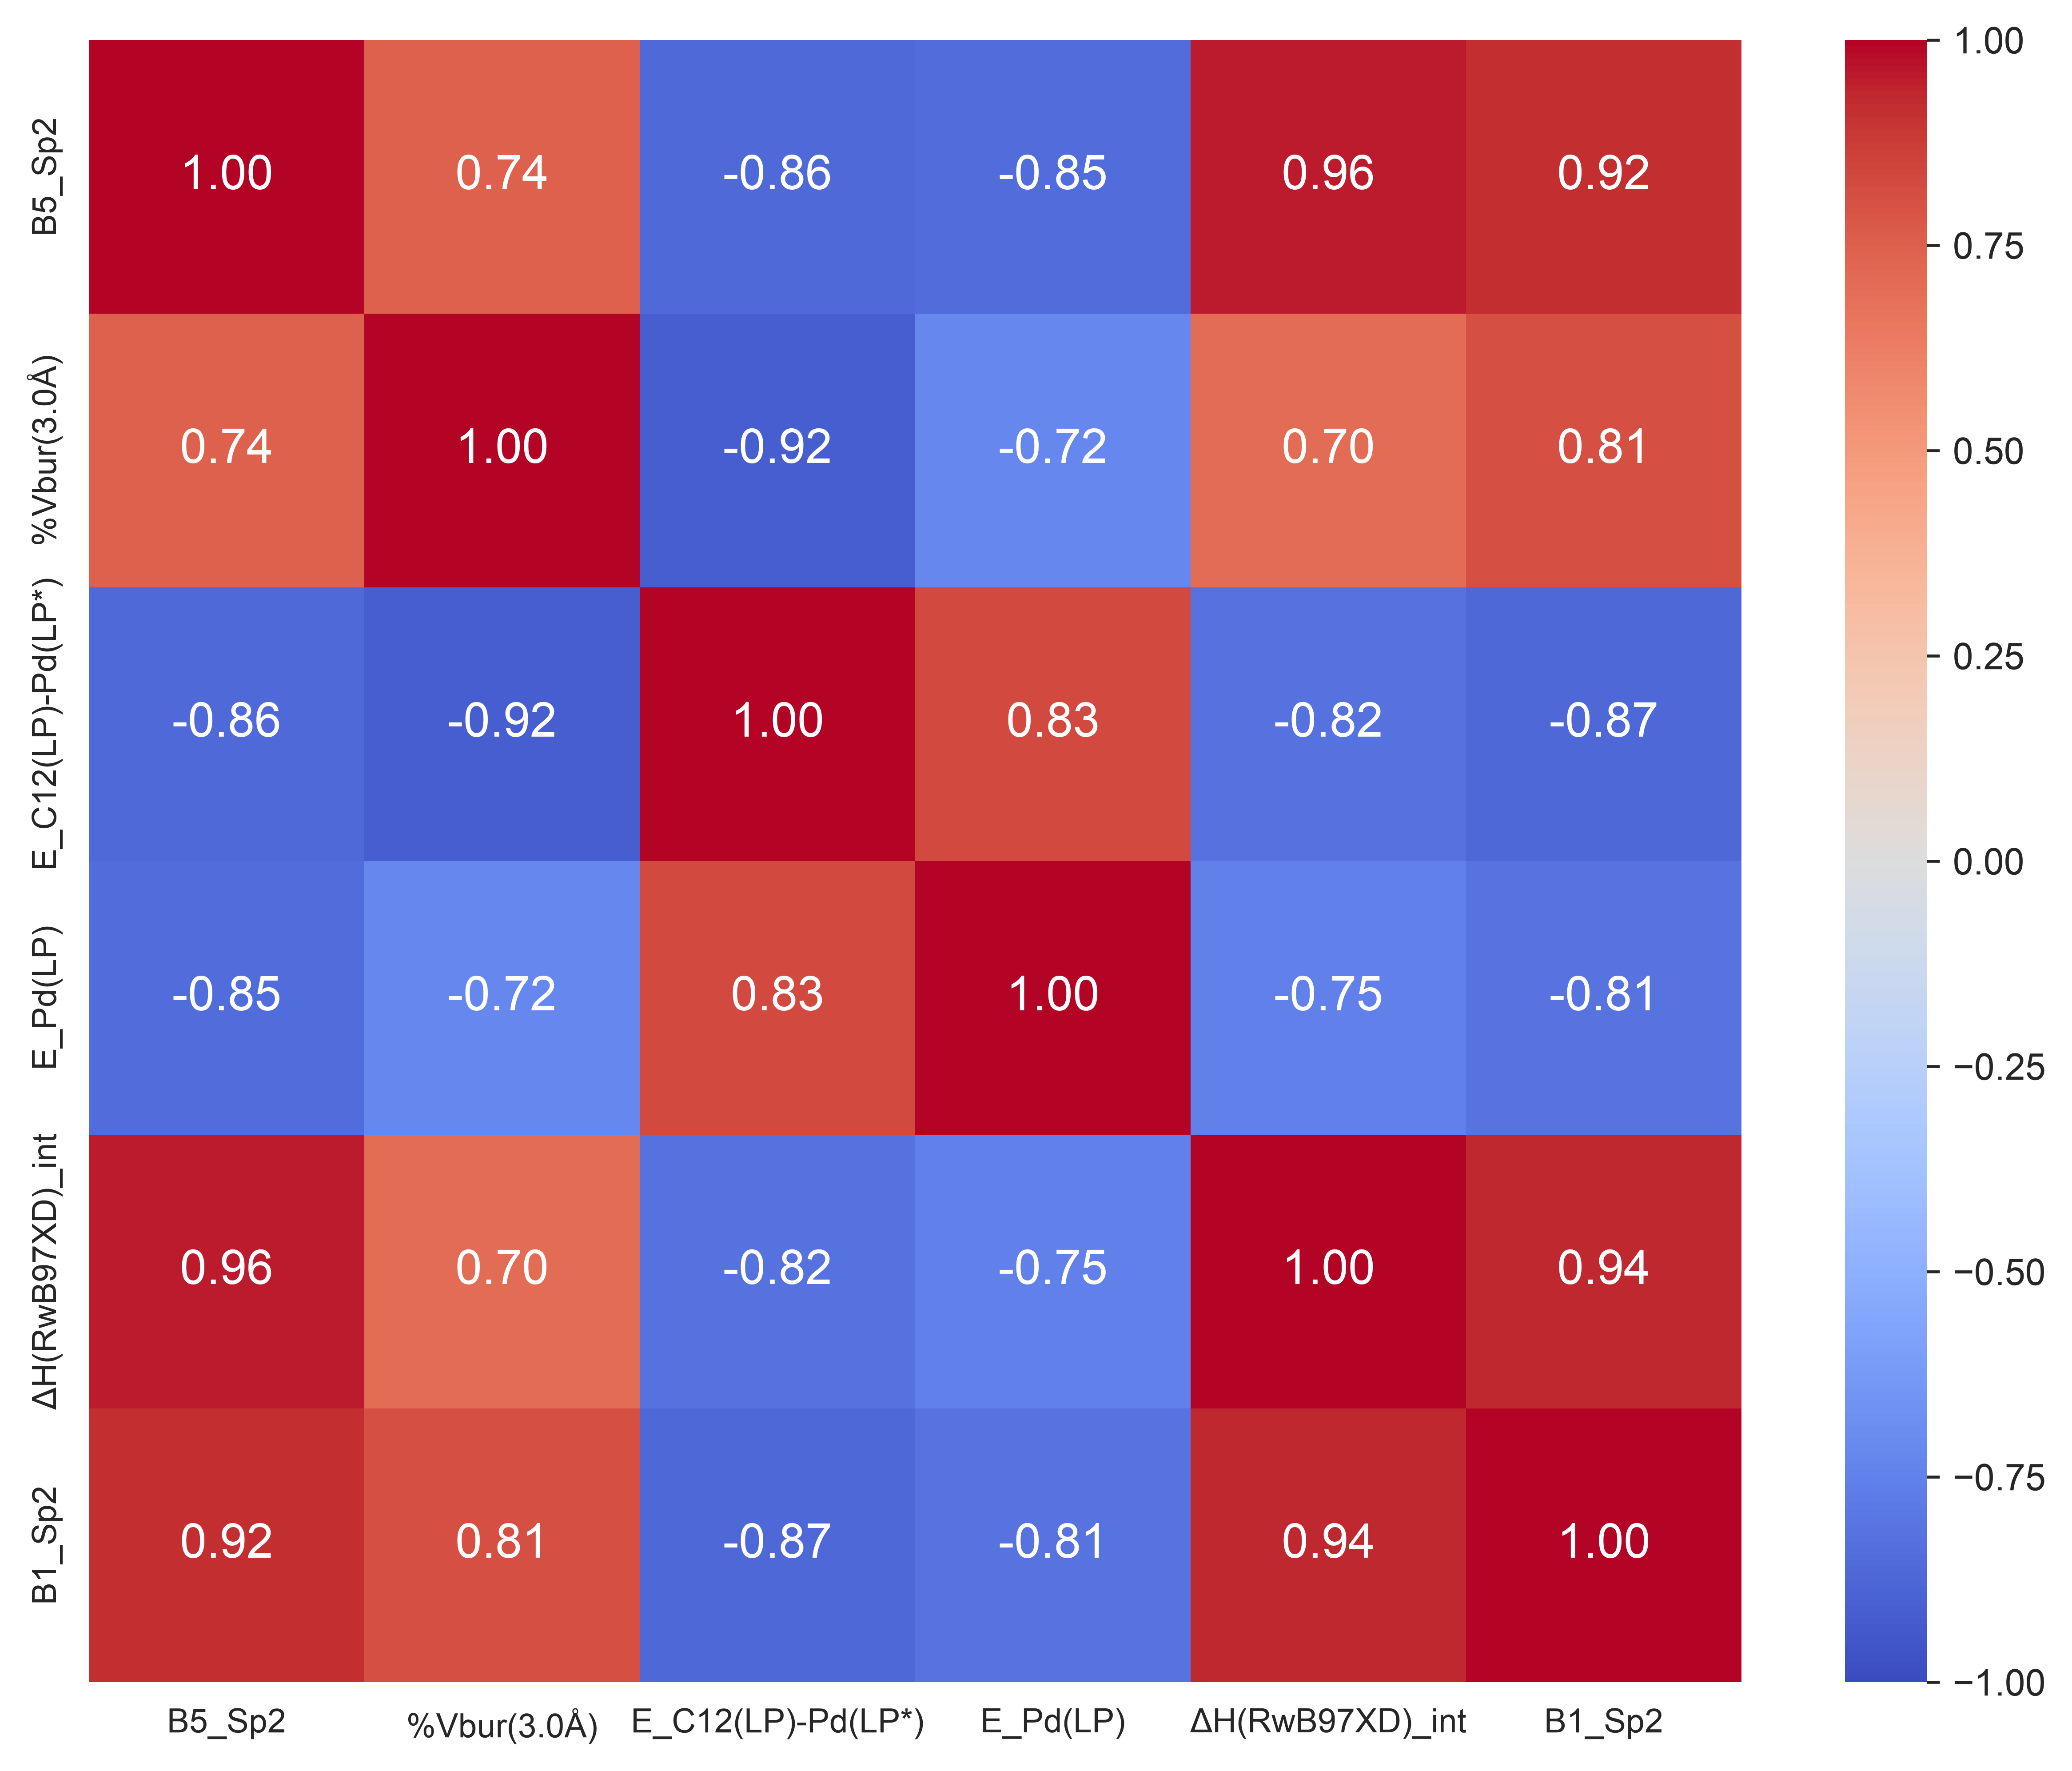

In [23]:
# Plot correlation matrix using seaborn heatmap
plt.figure(figsize=(10, 8), dpi=600)
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot_kws={"size": 13}
)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.savefig("Figure 4B", format="png", dpi=600, bbox_inches="tight")
plt.show()